# Wasserstein distance

The Wasserstein distance, also known as the Earth Mover's Distance (EMD), is a measure of the distance between two probability distributions. It's used in various fields, including machine learning (especially in Generative Adversarial Networks, or GANs) and optimal transport theory.

Imagine two probability distributions as piles of "dirt" spread over two different areas. The goal of the Wasserstein distance is to quantify the minimum "effort" needed to transform one distribution into the other by "moving the dirt" between them. The "effort" is measured as the amount of "dirt" moved multiplied by the distance it is moved.




### Objective:
The goal of the optimization is to find the **transport plan** $ \gamma $ that minimizes the total cost of transporting mass between points in two distributions, while satisfying the mass-preserving constraints.

### Key Elements:
1. **Distributions $ \mu $ and $ \nu $**:
   - These are two discrete probability distributions defined on finite sets $\{x_1, x_2, \dots, x_m\}$ and $\{y_1, y_2, \dots, y_n\}$, respectively. 
   - $ \mu_i $ represents the probability mass at point $ x_i $, and $ \nu_j $ represents the probability mass at point $ y_j $.

2. **Transport Plan $ \gamma_{ij} $**:
   - $ \gamma_{ij} $ represents the amount of mass transported from point $ x_i $ in distribution $ \mu $ to point $ y_j $ in distribution $ \nu $. 
   - The objective is to determine the values of $ \gamma_{ij} $ that minimize the overall cost of transporting mass between these distributions.

3. **Cost Function $ d(x_i, y_j) $**:
   - $ d(x_i, y_j) $ is the cost associated with moving a unit of mass from point $ x_i $ to point $ y_j $. This is typically defined using some metric, such as the Euclidean distance between the points $ x_i $ and $ y_j $, but could be any non-negative function representing the cost.

### The Optimization Problem:
The optimization problem aims to minimize the **total transport cost** by finding the optimal transport plan $ \gamma $.

#### Objective Function:
$$
\min \sum_{i=1}^{m} \sum_{j=1}^{n} d(x_i, y_j) \gamma_{ij}
$$
- This expression sums the cost of transporting mass from $ x_i $ to $ y_j $ across all $ i $ and $ j $, weighted by how much mass $ \gamma_{ij} $ is transported between these two points.
- The objective is to minimize this total transport cost.

#### Constraints:
The problem must satisfy the following constraints to ensure the correct mass is transported:

1. **Constraint 1**:
   $$
   \sum_{j=1}^{n} \gamma_{ij} = \mu_i \quad \forall i = 1, \dots, m
   $$
   - This ensures that the total mass transported out of point $ x_i $ is exactly equal to the amount of mass $ \mu_i $ available at $ x_i $. In other words, all the mass at each $ x_i $ must be moved somewhere.

2. **Constraint 2**:
   $$
   \sum_{i=1}^{m} \gamma_{ij} = \nu_j \quad \forall j = 1, \dots, n
   $$
   - This ensures that the total mass received at each $ y_j $ equals the required amount $ \nu_j $ from the distribution $ \nu $. In other words, the total mass arriving at $ y_j $ must match the target distribution.

3. **Non-Negativity Constraint**:
   $$
   \gamma_{ij} \geq 0 \quad \forall i = 1, \dots, m, j = 1, \dots, n
   $$
   - This ensures that the amount of mass transported between any two points is non-negative, as you can't move a negative amount of mass.

### Interpretation:
The Wasserstein distance in this discrete case is the **minimum total cost** required to transport the mass of $ \mu $ to match the mass distribution $ \nu $, given the constraints that ensure no mass is created or destroyed and that all the mass in $ \mu $ is perfectly transferred to match $ \nu $.

The solution $ \gamma $ represents the **optimal transport plan**: how much mass from each point $ x_i $ in $ \mu $ should be moved to each point $ y_j $ in $ \nu $ to achieve the minimum possible transport cost.


In [21]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

def compute_cost_matrix_unidimensional(points_mu, points_nu, p=2):
    """
    Compute the cost matrix using a given p-norm.

    Parameters:
    -----------
    points_mu : array-like, shape (m, d)
        Coordinates of points corresponding to the distribution mu (source points).
    points_nu : array-like, shape (n, d)
        Coordinates of points corresponding to the distribution nu (target points).
    p : float, optional (default=2)
        The p-norm to use for computing the cost (e.g., p=2 for Euclidean distance, p=1 for Manhattan distance).
    
    Returns:
    --------
    cost_matrix : array, shape (m, n)
        The cost matrix where cost_matrix[i, j] is the distance (cost) between points_mu[i] and points_nu[j].
    """
    m = len(points_mu)
    n = len(points_nu)
    
    cost_matrix = np.zeros((m, n))
    
    for i in range(m):
        for j in range(n):
            # Compute the p-norm distance between point i in mu and point j in nu
            cost_matrix[i, j] = abs(points_mu[i] - points_nu[j])**p
    return cost_matrix


def wasserstein_distance(mu, nu, cost_matrix):
    """
    Compute the 1-Wasserstein distance between two discrete distributions using Gurobi.

    Parameters:
    -----------
    mu : array-like, shape (m,)
        Probability distribution of the first set of points (source).
    nu : array-like, shape (n,)
        Probability distribution of the second set of points (target).
    cost_matrix : array-like, shape (m, n)
        The cost matrix where cost_matrix[i][j] is the cost of transporting mass from
        point i in mu to point j in nu.
    
    Returns:
    --------
    wasserstein_distance : float
        The computed Wasserstein distance between mu and nu.
    transport_plan : array, shape (m, n)
        The optimal transport plan.
    """
    m = len(mu)
    n = len(nu)

    # Create a Gurobi model
    model = gp.Model("wasserstein")

    # Disable Gurobi output (comment this if you want to see Gurobi's solver output)
    model.setParam("OutputFlag", 0)

    # Decision variables: transport plan gamma_ij
    gamma = model.addVars(m, n, lb=0, ub=GRB.INFINITY, name="gamma")

    # Objective: minimize the sum of the transport costs
    model.setObjective(gp.quicksum(cost_matrix[i, j] * gamma[i, j] for i in range(m) for j in range(n)), GRB.MINIMIZE)

    # Constraints: ensure that the total mass transported from each mu_i matches the corresponding mass in mu
    for i in range(m):
        model.addConstr(gp.quicksum(gamma[i, j] for j in range(n)) == mu[i], name=f"supply_{i}")

    # Constraints: ensure that the total mass transported to each nu_j matches the corresponding mass in nu
    for j in range(n):
        model.addConstr(gp.quicksum(gamma[i, j] for i in range(m)) == nu[j], name=f"demand_{j}")

    # Solve the optimization model
    model.optimize()

    # Extract the optimal transport plan and the Wasserstein distance
    if model.status == GRB.OPTIMAL:
        transport_plan = np.zeros((m, n))
        for i in range(m):
            for j in range(n):
                transport_plan[i, j] = gamma[i, j].X
        wasserstein_distance = model.objVal
        return wasserstein_distance, transport_plan
    else:
        raise Exception("Optimization problem did not converge!")


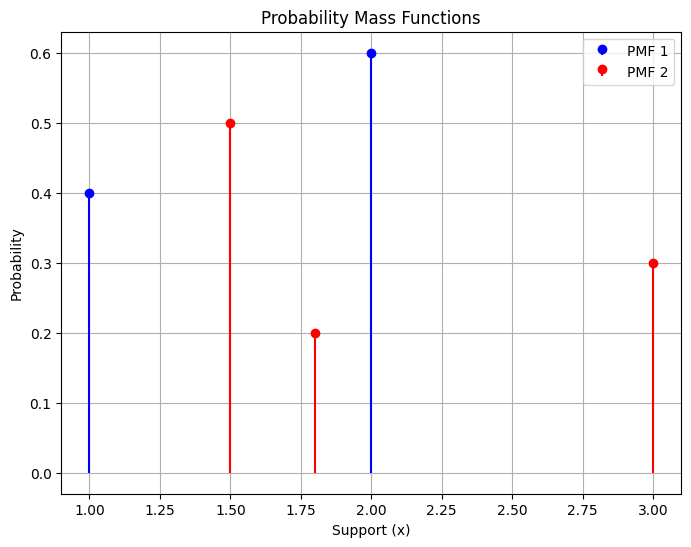

Wasserstein Distance: 0.433
Optimal Transport Plan:
[[0.4 0.  0. ]
 [0.1 0.2 0.3]]


In [28]:
# Two discrete distributions
mu = np.array([0.4, 0.6])   # Distribution over source points
points_mu = np.array([1, 2])

nu = np.array([0.5, 0.2, 0.3])  # Distribution over target points
points_nu = np.array([1.5, 1.8, 3])

# Create the plot
plt.figure(figsize=(8, 6))
    
# Plot the first PMF
plt.stem(points_mu, mu, linefmt='blue', markerfmt='blue', basefmt=" ", label="PMF 1")
plt.stem(points_nu, nu, linefmt='red', markerfmt='red', basefmt=" ", label="PMF 2")
    
# Add titles and labels
plt.title("Probability Mass Functions")
plt.xlabel("Support (x)")
plt.ylabel("Probability")

# Add a legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()


# Cost matrix (e.g., Euclidean distances between points)
cost_matrix = compute_cost_matrix_unidimensional(points_mu, points_nu, p=2)

# Compute the Wasserstein distance and the optimal transport plan
dist, plan = wasserstein_distance(mu, nu, cost_matrix)

# Output the results
print(f"Wasserstein Distance: {dist}")
print("Optimal Transport Plan:")
print(plan)